# xG Prediction

### Imports and loading

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

DATA_DIR = Path().resolve().parent / "Additional"
df = pd.read_parquet(DATA_DIR / "for_regression.parquet")
print(df.head(10))
print(df.shape)
print(list(df.columns))

print(f"Unique match,team,period, possession combos: {df.groupby(['match_id','OFF_TEAM_ID','period','possession']).ngroups}")
print(f"Total rows: {len(df)}")
print(f"\ntotal_xg stats:")
print(df['total_xg'].describe())
print(f"\nn_shots stats:")
print(df['n_shots'].describe())
print(f"\nRows per match_id (sample):")
print(df.groupby('match_id').size().describe())

shot_df = df[df['n_shots'] > 0]
print(f"Shot-producing rows: {len(shot_df)}")
print(f"Shot rate: {len(shot_df)/len(df):.4f}")
print(f"\ntotal_xg on shot rows:")
print(shot_df['total_xg'].describe())

print(f"\nlog_xg mean: {np.log(shot_df['total_xg']).mean():.4f}")
print(f"log_xg skewness: {np.log(shot_df['total_xg']).skew():.4f}")

   match_id           possession_type  period  possession  OFF_TEAM_ID  \
0   3754097      Middle Third - Short       2         109           38   
1     19783   Attacking Third - Short       1          31          971   
2   3879725      Middle Third - Short       1          45          291   
3   3901153   Defensive Third - Short       1          64         2736   
4   3754289      Middle Third - Short       1          62           22   
5   3845506     Middle Third - Direct       1          45          865   
6     69207   Defensive Third - Short       2         135          217   
7    267422  Defensive Third - Direct       1          18          223   
8     19782  Defensive Third - Direct       2         164          969   
9   3825817   Defensive Third - Short       2         192          322   

  OFF_MEN_WOMEN  OFF_BACKS  OFF_MIDFIELDERS  OFF_FORWARDS  OFF_GOALKEEPER  \
0             M        4.0              3.0           3.0             1.0   
1             W        4.0     

### Data Prep

In [2]:
shot_df = df[df['n_shots'] > 0].copy()
shot_df['log_xg'] = np.log(shot_df['total_xg'])

df_model = pd.get_dummies(shot_df, columns=['possession_type'], drop_first=True)
df_model['IS_MENS'] = (df_model['OFF_MEN_WOMEN'] == 'M').astype(int)

for c in ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

feature_cols = (
    ['duration_minutes', 'IS_MENS',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2', 'DIFF_C4', 'DIFF_C5']
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

print(f"Shape: {df_model.shape}")
print(f"Nulls: {df_model[feature_cols + ['log_xg']].isnull().sum().sum()}")
print(f"log_xg mean: {df_model['log_xg'].mean():.4f}, std: {df_model['log_xg'].std():.4f}")

Shape: (77317, 47)
Nulls: 0
log_xg mean: -2.8090, std: 1.1291


### Multicollinearity check

In [3]:
X_vif = df_model[feature_cols].astype(float)
vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string())
print(f"Shape: {df_model.shape}")

                                      feature       VIF
1                                     IS_MENS  4.937050
7     possession_type_Attacking Third - Short  1.928768
5                                     DIFF_C4  1.840830
8    possession_type_Defensive Third - Direct  1.838331
10    possession_type_Defensive Third - Short  1.675661
6                                     DIFF_C5  1.641066
11      possession_type_Middle Third - Direct  1.603208
0                            duration_minutes  1.535920
13       possession_type_Middle Third - Short  1.492726
12     possession_type_Middle Third - Patient  1.281692
3                                     DIFF_C1  1.113217
2                                     DIFF_C0  1.086575
4                                     DIFF_C2  1.075914
9   possession_type_Defensive Third - Patient  1.039205
Shape: (77317, 47)


### Train/Test and Scaling

In [4]:
X = df_model[feature_cols].astype(float)
y = df_model['log_xg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Fit

In [5]:
# sklearn for performance metrics
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²: {r2:.4f}")
print(f"RMSE (log scale): {rmse:.4f}")
print(f"RMSE (xg scale, approx): {np.exp(rmse):.4f}")

R²: 0.0155
RMSE (log scale): 1.1247
RMSE (xg scale, approx): 3.0794


### Inference

In [6]:
# statsmodels for inference
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_sm)
result = ols_model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 log_xg   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     60.46
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          2.14e-170
Time:                        19:16:34   Log-Likelihood:                -94790.
No. Observations:               61853   AIC:                         1.896e+05
Df Residuals:                   61838   BIC:                         1.897e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8094      0.005   -623.622      0.0

### Add variable names back

In [7]:
feature_names = ['const'] + feature_cols
results_df = pd.DataFrame({
    'variable': feature_names,
    'coefficient': result.params.values,
    'exp_coef': np.exp(result.params.values),
    'p_value': result.pvalues.values
}).query("variable != 'const'").sort_values('exp_coef', ascending=False)
print(results_df.to_string())

                                     variable  coefficient  exp_coef       p_value
12      possession_type_Middle Third - Direct     0.026075  1.026418  3.970106e-04
6                                     DIFF_C4     0.022182  1.022430  2.891171e-04
8     possession_type_Attacking Third - Short     0.021429  1.021660  1.128234e-02
1                            duration_minutes     0.018545  1.018718  2.004372e-04
11    possession_type_Defensive Third - Short     0.017397  1.017550  2.504669e-02
9    possession_type_Defensive Third - Direct     0.011191  1.011254  1.534508e-01
10  possession_type_Defensive Third - Patient    -0.007962  0.992070  9.361831e-02
5                                     DIFF_C2    -0.008416  0.991620  7.183552e-02
13     possession_type_Middle Third - Patient    -0.012925  0.987159  2.388731e-02
2                                     IS_MENS    -0.025081  0.975231  7.847362e-08
14       possession_type_Middle Third - Short    -0.025684  0.974643  3.385503e-04
7   

### Cross Validation

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2')
print(f"\nCV R² scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CV R² scores: [0.0118571  0.01205446 0.01343875 0.01009089 0.01654835]
Mean: 0.0128 (+/- 0.0022)


### Results and Viz

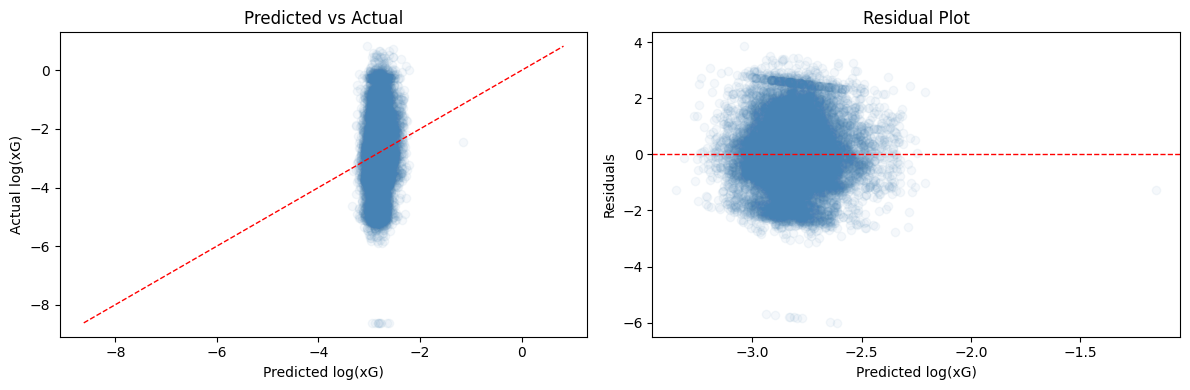

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, y_test, alpha=0.05, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=1)
axes[0].set_xlabel('Predicted log(xG)')
axes[0].set_ylabel('Actual log(xG)')
axes[0].set_title('Predicted vs Actual')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.05, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted log(xG)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

### Log Odds Graphs

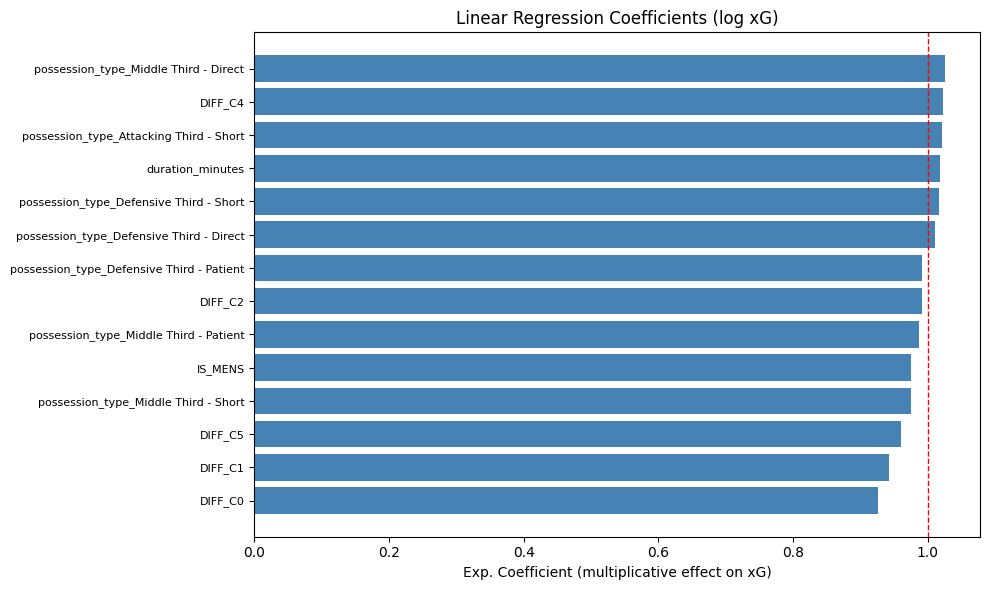

In [14]:
full_plot = results_df.sort_values('exp_coef')

plt.figure(figsize=(10, 6))
plt.barh(full_plot['variable'], full_plot['exp_coef'], color='steelblue')
plt.axvline(x=1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Exp. Coefficient (multiplicative effect on xG)')
plt.title('Linear Regression Coefficients (log xG)')
plt.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

### Summary

**Summary: We ran a linear regression model predicting log(xG) on shot-producing possessions (n = 77,317), using possession type, lineup composition, and duration as features. Response variable is log-transformed to address right skew; exponentiated coefficients represent multiplicative effects on xG.**

Highlights:

* Duration is positive and significant. Longer possessions are associated with sloghtly higher xG per possession, which lines up with the logistic regression results
* "Middle Third - Direct" and "Attacking Third - Short" are the highest-xG possession types relative to the "Attacking Third - Patient" baseline
* DIFF_C0 and DIFF_C1 are strongest neg. cluster effects. Offensive teams with more of these types relative to the defense correspond to lower xG quality.
* DIFF_C4 is positive and significant. Women's C4 type advantage --> slightly higher xG
* IS_MENS is negative and significant. Interestingly, men's possessions are associated with slightly lower xG per shot than women's, all else being equal

Model performance stats:

* R^2 of 0.013, which is still stable across 5-fold CV (mean 0.013, std 0.002)
* Low R^2 is somewhat expected: possession style/lineup composition explain a small but statistically significant share of xG variance. The dominant drivers of individual shot quality (typical xG uses shot location, technique, goalkeeper positioning, defensive pressure) are not captured at the possession level
* The model is statistically significant overall (F-statistic p ~ 0) and most coefficients are significant, confirming that there is real, but modest signal

To note:

* Reference category is "Attacking Third - Patient" throughout
* DIFF columns represent offensive minus defensive player counts per type, w/ C3 as baseline reference
* We filteres the dataset to shot-producing possessions only; zero-xG possessions were excluded by design
* 254 possessions dropped where a substitution occurred mid-possession; the lineup is attributed to the lineup at start of possession
* C4 and C5 represent women's player archetypes; for men's possessions these values are always 0